## DM-53745: DDF template vetting

Eric Bellm, 2026-01-21


In [24]:
import lsst.afw.display
import lsst.daf.butler
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from lsst.ip.diffim.utils import getPsfFwhm
import pandas as pd

In [124]:
default_collection = 'u/yusra/v30_0_0_rc2/DM-53748'
select20_collection = 'u/yusra/v30_0_0_rc2/DM-53748/select20'
noMaxVisits_collection = 'u/yusra/v30_0_0_rc2/DM-53748/noMaxVisits'

#butler = lsst.daf.butler.Butler("dp2_prep", collections=noMaxVisits_collection)
#name = 'noMaxVisits'

butler = lsst.daf.butler.Butler("dp2_prep", collections=select20_collection)
name = 'select20'

https://usdf-rsp.slac.stanford.edu/portal/app/onlinehelp/#id=visualization.fitsViewer

In [125]:
#sc = SkyCoord('10h06m26.72s +2d19m55.1s', frame='icrs') #COSMOS
#ra = sc.ra.degree
#dec = sc.dec.degree
#band = "'z'"

#tract = 9813 # our favorite COSMOS tract
tract = 2395

other fairly complete tracts:


2234
2394-96
2877
3345-46
3724-25
5063
8524
9813
10320-21
10562-63
10804

In [126]:
#refs = butler.query_datasets('template_coadd')
refs = butler.query_datasets('template_coadd',  where=f"tract = {tract} and skymap='lsst_cells_v2'")

In [127]:
#refs = butler.query_datasets('initialPviSummary_metrics')

In [128]:
len(refs)

500

In [129]:
%%time
fwhms = []
for ref in refs:
    psf = butler.get('template_coadd.psf',dataId=ref.dataId)
    fwhm = getPsfFwhm(psf)
    row = {}
    for col in ['band', 'tract','patch']:
        row[col] = ref.dataId[col]
    row['fwhm'] = fwhm
    fwhms.append(row)

CPU times: user 2min 25s, sys: 5.57 s, total: 2min 31s
Wall time: 6min 6s


In [130]:
df = pd.DataFrame(fwhms)

In [131]:
df['fwhm'] *= 0.2

In [132]:
df

,band,tract,patch,fwhm
0,g,2395,0,1.084149
1,g,2395,1,1.066999
2,g,2395,2,1.054535
3,g,2395,3,1.084478
4,g,2395,4,1.050299
...,...,...,...,...
495,z,2395,95,0.882554
496,z,2395,96,0.865910
497,z,2395,97,0.883082
498,z,2395,98,0.901223


In [133]:
df.to_csv(f'{name}_tract_{tract}.csv')

(array([  5.,  72., 107., 106.,  12.,  56., 121.,  19.,   0.,   2.]),
 array([0.71094986, 0.7616642 , 0.81237854, 0.86309288, 0.91380722,
        0.96452156, 1.0152359 , 1.06595024, 1.11666458, 1.16737892,
        1.21809326]),
 <BarContainer object of 10 artists>)

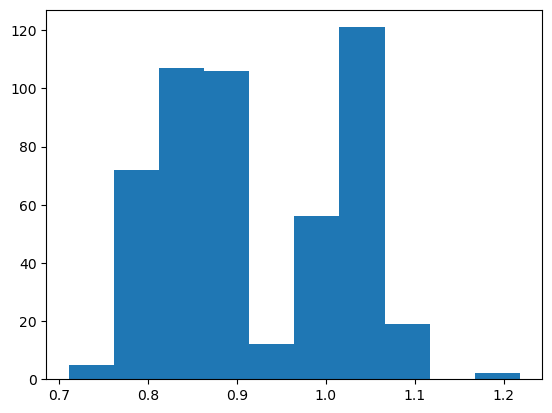

In [134]:
plt.hist(df.fwhm)

(array([  1.,   2.,   7.,  29.,  42.,  37., 132., 157.,  75.,  18.]),
 array([0.63860283, 0.68219629, 0.72578975, 0.76938322, 0.81297668,
        0.85657015, 0.90016361, 0.94375708, 0.98735054, 1.03094401,
        1.07453747]),
 <BarContainer object of 10 artists>)

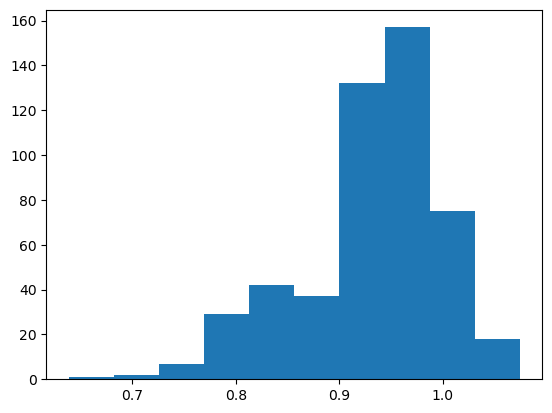

In [106]:
plt.hist(df.fwhm)

In [135]:
df_nomax = pd.read_csv(f'noMaxVisits_tract_{tract}.csv')
df = pd.read_csv(f'select20_tract_{tract}.csv')

In [136]:
df

,Unnamed: 0,band,tract,patch,fwhm
0,0,g,2395,0,1.084149
1,1,g,2395,1,1.066999
2,2,g,2395,2,1.054535
3,3,g,2395,3,1.084478
4,4,g,2395,4,1.050299
...,...,...,...,...,...
495,495,z,2395,95,0.882554
496,496,z,2395,96,0.865910
497,497,z,2395,97,0.883082
498,498,z,2395,98,0.901223


In [137]:
df_nomax

,Unnamed: 0,band,tract,patch,fwhm
0,0,g,2395,0,1.084149
1,1,g,2395,1,1.066999
2,2,g,2395,2,1.054535
3,3,g,2395,3,1.107595
4,4,g,2395,4,1.060888
...,...,...,...,...,...
495,495,z,2395,95,0.924558
496,496,z,2395,96,0.914879
497,497,z,2395,97,0.942192
498,498,z,2395,98,0.931010


In [138]:
from lsst.utils.plotting import get_multiband_plot_colors, get_multiband_plot_symbols, get_multiband_plot_linestyles
colors_white = get_multiband_plot_colors()
symbols = get_multiband_plot_symbols()

In [139]:
df.sort_values(['band','tract'],inplace=True)
df_nomax.sort_values(['band','tract'],inplace=True)

Text(0, 0.5, 'noMax FWHM (arcseconds)')

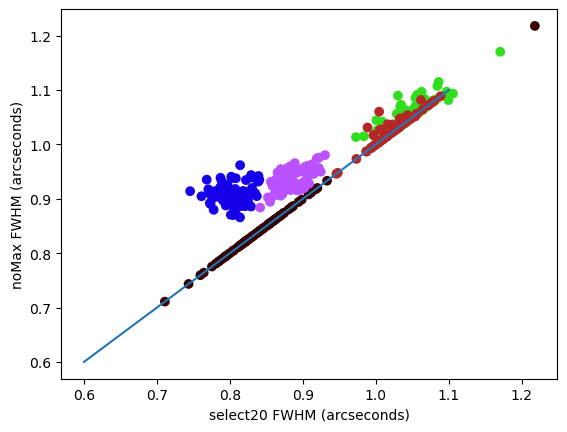

In [140]:
plt.scatter(df['fwhm'], df_nomax['fwhm'],c=df['band'].apply(lambda x: colors_white[x]))
plt.plot([0.6,1.1],[0.6,1.1])
plt.xlabel('select20 FWHM (arcseconds)')
plt.ylabel('noMax FWHM (arcseconds)')
